# 데이터 전처리 기법 총정리

머신러닝 모델의 성능은 학습 데이터의 품질에 직접적으로 의존합니다. 원본 데이터에는 결측치, 이상치, 비정규 분포, 범주형 변수 등 모델이 직접 처리할 수 없는 요소가 포함되어 있으며, 이를 사전에 정제하지 않으면 모델의 학습 자체가 불가능하거나 편향된 예측 결과를 출력합니다. 본 문서에서는 수치형 데이터 정제, 범주형 데이터 인코딩, 스케일링, 변수 선택에 이르는 전처리 과정을 항공 운항 데이터를 기반으로 분석합니다.

# SECTION 01. 수치형 데이터 정제하기

수치형 데이터의 전처리는 결측치 처리, 이상치 탐지 및 제거, 구간화(binning)의 세 단계로 구성됩니다. 각 단계에서 데이터의 무결성을 확보하지 않으면 후속 분석의 신뢰도가 저하됩니다.

## 1. 결측치 파악하기

### 데이터 준비

본 문서에서는 저작권 문제를 회피하기 위해 항공 운항 데이터를 직접 생성합니다. 실제 항공 데이터셋과 유사한 구조(항공사, 출발지, 도착지, 좌석 등급, 경유 횟수, 편명, 비행시간, 잔여일수, 가격)를 갖는 300,153건의 데이터프레임을 구성합니다.

In [1]:
%matplotlib inline

# 판다스, 넘파이, 랜덤 모듈 불러오기
import pandas as pd
import numpy as np
import random

# 동일한 결과 재현을 위해 시드 고정
random.seed(2023)
np.random.seed(2023)

# 항공 운항 데이터프레임 직접 생성 (300,153건)
n = 300153

# 각 칼럼에 사용할 범주 정의
airlines = ['Korean_Air', 'Asiana', 'JAL', 'ANA', 'Singapore_Airlines', 'Cathay_Pacific']
cities = ['Incheon', 'Tokyo', 'Osaka', 'Singapore', 'Hong_Kong', 'Bangkok']
classes = ['Economy', 'Business']
stops_list = ['zero', 'one', 'two_or_more']

# 항공사별 IATA 2자리 코드 매핑
airline_codes = {
    'Korean_Air': 'KE',
    'Asiana': 'OZ',
    'JAL': 'JL',
    'ANA': 'NH',
    'Singapore_Airlines': 'SQ',
    'Cathay_Pacific': 'CX'
}

# 항공사 데이터 생성
airline_choices = np.random.choice(airlines, n)

# 범주형 칼럼: 지정된 리스트에서 랜덤 선택
df = pd.DataFrame({
    'airline': airline_choices,
    'source_city': np.random.choice(cities, n),
    'destination_city': np.random.choice(cities, n),
    'class': np.random.choice(classes, n, p=[0.7, 0.3]),  # Economy 비율 70%
    'stops': np.random.choice(stops_list, n, p=[0.4, 0.45, 0.15]),
    'flight': [
        # 항공사 코드(IATA)와 편명 번호(3~4자리 숫자)를 "-"로 연결
        f"{airline_codes[al]}-{random.randint(100, 9999)}"
        for al in airline_choices
    ],
    # 수치형 칼럼: 정규분포 기반으로 생성 후 범위 제한
    'duration': np.clip(np.random.normal(10, 5, n), 0.5, 50).round(2),
    'days_left': np.random.randint(1, 50, n).astype(float),
    'price': np.clip(np.random.normal(7500, 5000, n), 1000, 120000).astype(float)
})

# 출발지와 도착지가 동일한 행 보정
mask = df['source_city'] == df['destination_city']
df.loc[mask, 'destination_city'] = np.random.choice(
    cities, mask.sum()
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   source_city       300153 non-null  str    
 2   destination_city  300153 non-null  str    
 3   class             300153 non-null  str    
 4   stops             300153 non-null  str    
 5   flight            300153 non-null  str    
 6   duration          300153 non-null  float64
 7   days_left         300153 non-null  float64
 8   price             300153 non-null  float64
dtypes: float64(3), str(6)
memory usage: 32.6 MB


- `np.random.choice`: 지정된 리스트에서 확률 가중치를 적용하여 랜덤 샘플링합니다. `p` 파라미터로 각 요소의 선택 확률을 지정합니다.
- `np.clip`: 정규분포에서 생성된 값 중 범위를 벗어나는 값을 최소/최대 경계로 절삭(clipping)합니다. 음수 비행시간 같은 비논리적 값의 생성을 방지합니다.
- 출발지와 도착지가 동일한 행은 도착지를 재배정하여 논리적 무결성을 확보합니다.

### 결측치 생성

전처리 연습을 위해 생성된 데이터에 의도적으로 결측치를 삽입합니다.

In [2]:
# 랜덤한 위치에 결측치 5,000개 생성
df_na = df.copy()
# 정수형 칼럼을 float로 변환하여 NaN 삽입이 가능하도록 설정
df_na['days_left'] = df_na['days_left'].astype(float)
df_na['price'] = df_na['price'].astype(float)
for i in range(0, 5000):
    # 0~len(df)-1 행, 0~len(df.columns)-1 칼럼 범위에서 랜덤 위치 선택 후 NaN 삽입
    df_na.iloc[random.randint(0, len(df)-1), random.randint(0, len(df.columns)-1)] = np.nan

# 결측치 처리 여부 검증용으로 1번, 3번 인덱스의 전체 칼럼을 NaN 처리
df_na.iloc[1] = np.nan
df_na.iloc[3] = np.nan

- `iloc`을 사용하여 정수 기반 위치 인덱싱으로 특정 셀에 접근합니다.
- 1번과 3번 인덱스는 모든 칼럼을 NaN으로 설정하여 `dropna(how='all')` 테스트에 활용합니다.

### 1) 결측치 존재 여부 확인하기

In [3]:
# 데이터 정보 확인
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299631 non-null  str    
 1   source_city       299567 non-null  str    
 2   destination_city  299572 non-null  str    
 3   class             299617 non-null  str    
 4   stops             299591 non-null  str    
 5   flight            299556 non-null  str    
 6   duration          299609 non-null  float64
 7   days_left         299612 non-null  float64
 8   price             299607 non-null  float64
dtypes: float64(3), str(6)
memory usage: 32.8 MB


`info()` 메서드는 각 칼럼의 데이터 타입과 Non-Null 개수를 출력합니다. 전체 행 수 대비 Non-Null 개수가 적은 칼럼에 결측치가 존재합니다.

### 2) 결측치 수 확인하기

In [4]:
# 칼럼별 결측치 수 확인
df_na.isnull().sum(axis=0)

airline             522
source_city         586
destination_city    581
class               536
stops               562
flight              597
duration            544
days_left           541
price               546
dtype: int64

- `isnull()`: 각 셀의 NaN 여부를 Boolean 값으로 반환합니다.
- `sum(axis=0)`: 칼럼 단위(축 0)로 True 값을 합산하여 결측치 개수를 산출합니다.

---

## 2. 결측치 처리하기

결측치 처리 방식은 삭제, 칼럼 제거, 대체의 세 가지로 구분됩니다. 각 방식은 데이터 손실량과 분석 목적에 따라 선택합니다.

In [5]:
# 원본 데이터 보존을 위한 복사본 생성
df_na_origin = df_na.copy()

### 1) 결측치 삭제하기

In [6]:
# 결측치를 하나라도 포함하는 행 전체 삭제
df_na = df_na.dropna()
df_na.info()

<class 'pandas.DataFrame'>
Index: 295197 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           295197 non-null  str    
 1   source_city       295197 non-null  str    
 2   destination_city  295197 non-null  str    
 3   class             295197 non-null  str    
 4   stops             295197 non-null  str    
 5   flight            295197 non-null  str    
 6   duration          295197 non-null  float64
 7   days_left         295197 non-null  float64
 8   price             295197 non-null  float64
dtypes: float64(3), str(6)
memory usage: 34.5 MB


`dropna()`의 기본 동작은 하나의 칼럼이라도 NaN인 행을 전부 삭제합니다. 결측치가 분산되어 있으면 대량의 데이터가 소실될 수 있으므로 주의해야 합니다.

In [7]:
# 원본 데이터 복원
df_na = df_na_origin.copy()

# 모든 칼럼이 결측치인 행만 삭제
df_na = df_na.dropna(how='all')
df_na.info()

<class 'pandas.DataFrame'>
Index: 300151 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299631 non-null  str    
 1   source_city       299567 non-null  str    
 2   destination_city  299572 non-null  str    
 3   class             299617 non-null  str    
 4   stops             299591 non-null  str    
 5   flight            299556 non-null  str    
 6   duration          299609 non-null  float64
 7   days_left         299612 non-null  float64
 8   price             299607 non-null  float64
dtypes: float64(3), str(6)
memory usage: 35.1 MB


- `how='all'`: 행의 모든 칼럼 값이 NaN인 경우에만 해당 행을 삭제합니다. 부분 결측은 유지되므로 데이터 손실을 최소화합니다.

In [8]:
# 1번, 3번 인덱스 삭제 결과 확인 (해당 행은 전체가 NaN이었음)
df_na.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.19,5.0,1000.000000
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.11,4.0,8444.172038
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.56,41.0,6846.964971
5,Singapore_Airlines,Hong_Kong,Osaka,Economy,one,SQ-5625,9.49,8.0,1000.000000
6,Cathay_Pacific,Tokyo,Osaka,Economy,two_or_more,CX-1739,9.95,29.0,5701.941112


### 2) 칼럼 제거하기

결측치 비율이 높은 칼럼 자체를 분석 대상에서 제외하는 방식입니다.

In [9]:
# 원본 데이터 복원
df_na = df_na_origin.copy()

# stops, flight 칼럼 제거
df_na = df_na.drop(['stops', 'flight'], axis=1)
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299631 non-null  str    
 1   source_city       299567 non-null  str    
 2   destination_city  299572 non-null  str    
 3   class             299617 non-null  str    
 4   duration          299609 non-null  float64
 5   days_left         299612 non-null  float64
 6   price             299607 non-null  float64
dtypes: float64(3), str(4)
memory usage: 24.8 MB


- `axis=1`: 칼럼 축을 지정합니다. `axis=0`은 행 삭제, `axis=1`은 칼럼 삭제입니다.
- 분석 목적과 무관하거나 결측 비율이 과도한 칼럼을 제거하면 이후 행 삭제 시 데이터 손실을 줄일 수 있습니다.

In [10]:
# 결측치를 하나라도 포함하는 행 삭제
df_na = df_na.dropna()
df_na.info()

<class 'pandas.DataFrame'>
Index: 296329 entries, 0 to 300152
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           296329 non-null  str    
 1   source_city       296329 non-null  str    
 2   destination_city  296329 non-null  str    
 3   class             296329 non-null  str    
 4   duration          296329 non-null  float64
 5   days_left         296329 non-null  float64
 6   price             296329 non-null  float64
dtypes: float64(3), str(4)
memory usage: 26.8 MB


### 3) 결측치 대체하기

데이터를 삭제하는 대신 통계값으로 결측치를 채우는 방식입니다.

In [11]:
# 원본 데이터 복원
df_na = df_na_origin.copy()

# 수치형 칼럼의 평균값으로 결측치 대체
df_na = df_na.fillna(df_na.mean(numeric_only=True))
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299631 non-null  str    
 1   source_city       299567 non-null  str    
 2   destination_city  299572 non-null  str    
 3   class             299617 non-null  str    
 4   stops             299591 non-null  str    
 5   flight            299556 non-null  str    
 6   duration          300153 non-null  float64
 7   days_left         300153 non-null  float64
 8   price             300153 non-null  float64
dtypes: float64(3), str(6)
memory usage: 32.8 MB


- `mean(numeric_only=True)`: 수치형 칼럼만 선택하여 평균값을 산출합니다. 범주형 칼럼의 결측치는 대체되지 않습니다.
- `fillna()`: NaN 값을 인자로 전달된 값으로 대체합니다. Series를 전달하면 칼럼명이 일치하는 칼럼에 해당 값이 적용됩니다.

In [12]:
# 대체 결과 확인 (1번, 3번 인덱스의 수치형 칼럼이 평균값으로 대체됨)
df_na.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.190000,5.000000,1000.000000
1,NaN,NaN,NaN,NaN,NaN,NaN,10.041115,25.029702,7731.898431
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.110000,4.000000,8444.172038
3,NaN,NaN,NaN,NaN,NaN,NaN,10.041115,25.029702,7731.898431
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.560000,41.000000,6846.964971


In [13]:
# bfill(Backward Fill)을 이용한 결측치 대체
df_na = df_na.bfill()
df_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   source_city       300153 non-null  str    
 2   destination_city  300153 non-null  str    
 3   class             300153 non-null  str    
 4   stops             300153 non-null  str    
 5   flight            300153 non-null  str    
 6   duration          300153 non-null  float64
 7   days_left         300153 non-null  float64
 8   price             300153 non-null  float64
dtypes: float64(3), str(6)
memory usage: 32.6 MB


- `bfill()`: 결측치를 해당 칼럼의 바로 다음 행(아래쪽) 값으로 대체합니다. 시계열 데이터에서 자주 사용됩니다.
- 유사하게 `ffill()`은 이전 행(위쪽) 값으로 대체합니다.

In [14]:
# bfill 대체 결과 확인
df_na.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.190000,5.000000,1000.000000
1,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,10.041115,25.029702,7731.898431
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.110000,4.000000,8444.172038
3,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,10.041115,25.029702,7731.898431
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.560000,41.000000,6846.964971


---

## 3. 이상치 파악하기

이상치(Outlier)는 데이터의 일반적인 분포에서 크게 벗어난 관측값입니다. 이상치가 포함된 상태로 모델을 학습하면 평균, 분산 등의 통계량이 왜곡되어 모델 성능이 저하됩니다.

### 1) Z-score로 확인하기

In [15]:
# Z-score 기준 신뢰 수준 95%에서 이상치 확인 (|Z| > 1.96)
df[(abs((df['price'] - df['price'].mean()) / df['price'].std())) > 1.96]

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price
66,Asiana,Singapore,Hong_Kong,Economy,zero,OZ-2310,4.54,48.0,19882.166297
82,Cathay_Pacific,Tokyo,Hong_Kong,Economy,zero,CX-4710,14.36,43.0,18382.310261
85,Asiana,Singapore,Tokyo,Economy,zero,OZ-2869,7.42,30.0,22251.925097
116,Cathay_Pacific,Singapore,Osaka,Economy,one,CX-4490,13.77,42.0,23203.391050
129,ANA,Singapore,Hong_Kong,Economy,one,NH-5561,8.96,22.0,19352.507030
...,...,...,...,...,...,...,...,...,...
299897,Singapore_Airlines,Incheon,Bangkok,Business,zero,SQ-7407,3.17,13.0,18874.802034
299961,ANA,Tokyo,Singapore,Economy,one,NH-5767,15.12,3.0,18780.640149
299971,ANA,Tokyo,Hong_Kong,Business,one,NH-2467,15.15,20.0,19163.364442
299979,Singapore_Airlines,Bangkok,Tokyo,Economy,one,SQ-5053,12.43,48.0,17846.376694


- Z-score(표준 점수) 수식:
$$Z = \frac{X - \mu}{\sigma}$$
- Z-score는 각 관측값이 평균으로부터 표준편차의 몇 배만큼 떨어져 있는지를 나타냅니다.
- 정규분포를 가정한 신뢰 수준 95% 기준에서 $|Z| > 1.96$을 만족하는 관측값을 이상치로 판단합니다.
- 정규분포를 가정하므로, 데이터의 분포가 정규분포에서 크게 벗어나는 경우 적합하지 않습니다.

### 2) IQR(Inter Quartile Range)로 확인하기

In [16]:
# IQR 기준 이상치를 탐지하는 함수 정의
def findOutliers(x, column):
    # 제1사분위수(25%) 산출
    q1 = x[column].quantile(0.25)

    # 제3사분위수(75%) 산출
    q3 = x[column].quantile(0.75)

    # IQR의 1.5배수 계산 (Tukey's Fence 기준)
    iqr = 1.5 * (q3 - q1)

    # Q3 + 1.5*IQR 초과 또는 Q1 - 1.5*IQR 미만인 관측값 추출
    y = x[(x[column] > (q3 + iqr)) | (x[column] < (q1 - iqr))]

    # 이상치 개수 반환
    return len(y)

- 사분위 범위(IQR) 및 이상치 판정 경계 수식:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Outlier} < Q_1 - 1.5 \times \text{IQR} \quad \text{또는} \quad \text{Outlier} > Q_3 + 1.5 \times \text{IQR}$$
- IQR 방식은 분포의 형태를 가정하지 않으므로 비정규분포 데이터에도 적용 가능합니다.
- 1.5배수 기준은 John Tukey가 제안한 표준 기준이며, 3배수를 사용하면 극단적 이상치(Extreme Outlier)만 탐지합니다.

In [17]:
# 수치형 칼럼별 이상치 개수 확인
print("price IQR Outliers : ", findOutliers(df, 'price'))
print("duration IQR Outliers : ", findOutliers(df, 'duration'))
print("days_left IQR Outliers : ", findOutliers(df, 'days_left'))

price IQR Outliers :  1016
duration IQR Outliers :  1082


days_left IQR Outliers :  0


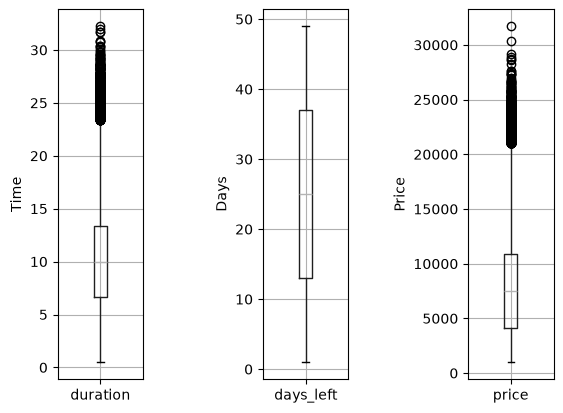

In [18]:
# 박스 플롯을 활용한 시각적 이상치 확인
import matplotlib.pyplot as plt

plt.figure()

# 1행 5열 레이아웃의 1번 위치: 비행시간
plt.subplot(151)
df[['duration']].boxplot()
plt.ylabel("Time")

# 1행 5열 레이아웃의 3번 위치: 잔여일수
plt.subplot(153)
df[['days_left']].boxplot()
plt.ylabel("Days")

# 1행 5열 레이아웃의 5번 위치: 가격
plt.subplot(155)
df[['price']].boxplot()
plt.ylabel("Price")

plt.show()

- 박스 플롯의 수염(whisker) 바깥에 위치한 점이 IQR 기준 이상치입니다.
- `subplot(151)`에서 `1`, `5`, `1`은 각각 행 수, 열 수, 현재 위치를 의미합니다. 칼럼 사이에 간격을 두기 위해 짝수 위치를 비워둡니다.

---

## 4. 이상치 처리하기

이상치 처리 방식은 삭제와 대체로 구분됩니다.

In [19]:
# 원본 데이터 보존
df_origin = df.copy()

### 1) 이상치 데이터 삭제하기

In [20]:
# Z-score 기준 신뢰도 95% 이상치의 인덱스 추출
outlier = df[
    (abs((df['price'] - df['price'].mean()) / df['price'].std())) > 1.96
].index

# 추출한 인덱스의 행 삭제
clean_df = df.drop(outlier)
clean_df.info()

<class 'pandas.DataFrame'>
Index: 290313 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           290313 non-null  str    
 1   source_city       290313 non-null  str    
 2   destination_city  290313 non-null  str    
 3   class             290313 non-null  str    
 4   stops             290313 non-null  str    
 5   flight            290313 non-null  str    
 6   duration          290313 non-null  float64
 7   days_left         290313 non-null  float64
 8   price             290313 non-null  float64
dtypes: float64(3), str(6)
memory usage: 33.9 MB


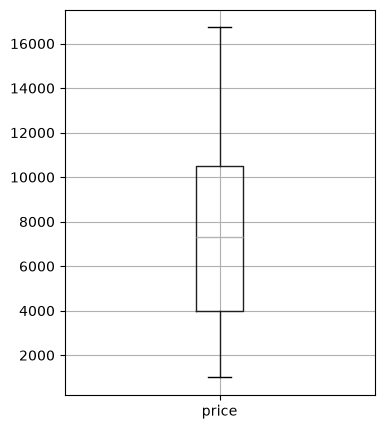

In [21]:
# 박스 플롯으로 이상치 제거 결과 확인
plt.figure(figsize=(4, 5))
clean_df[['price']].boxplot()
plt.show()

### 2) 이상치 데이터 대체하기

삭제 대신 경계값으로 대체하면 데이터의 행 수를 보존할 수 있습니다.

In [22]:
# IQR 기준 이상치를 경계값으로 대체하는 함수 정의
def changeOutliers(x, column):
    # 제1사분위수(25%) 산출
    q1 = x[column].quantile(0.25)

    # 제3사분위수(75%) 산출
    q3 = x[column].quantile(0.75)

    # IQR의 1.5배수 계산
    iqr = 1.5 * (q3 - q1)

    # 대체 경계값 설정
    Min = (q1 - iqr)
    Max = q3 + iqr

    # Max 초과값은 Max로, Min 미만값은 Min으로 대체
    x.loc[(x[column] > Max), column] = Max
    x.loc[(x[column] < Min), column] = Min

    return x

# price 칼럼에 이상치 대체 적용
clean_df = changeOutliers(df, 'price')
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   source_city       300153 non-null  str    
 2   destination_city  300153 non-null  str    
 3   class             300153 non-null  str    
 4   stops             300153 non-null  str    
 5   flight            300153 non-null  str    
 6   duration          300153 non-null  float64
 7   days_left         300153 non-null  float64
 8   price             300153 non-null  float64
dtypes: float64(3), str(6)
memory usage: 32.6 MB


- Winsorizing(윈저화)으로도 불리는 기법입니다. 이상치를 삭제하지 않고 경계값으로 끌어들여 전체 데이터 건수를 유지합니다.
- `loc` 인덱서를 사용하여 조건에 해당하는 행의 특정 칼럼 값을 직접 수정합니다.

In [23]:
# 대체 후 이상치 개수 확인 (0이 되어야 정상)
print("price IQR Outliers : ", findOutliers(clean_df, 'price'))

price IQR Outliers :  0


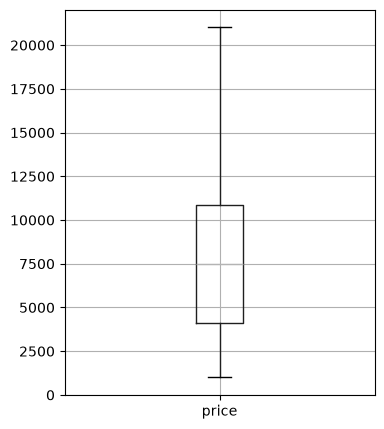

In [24]:
# 박스 플롯으로 이상치 대체 결과 확인
plt.figure(figsize=(4, 5))
clean_df[['price']].boxplot()
plt.show()

---

## 5. 구간화(Binning)하기

연속형 변수를 범주형 변수로 변환하는 작업입니다. 모델의 과적합을 방지하거나 비선형 관계를 포착하는 데 활용됩니다.

### 1) 동일 길이로 구간화하기

In [25]:
# 비행시간을 0~5, 5~10, 10 이상의 3개 구간으로 분할하여 distance 칼럼 생성
df['distance'] = pd.cut(
    df['duration'],
    bins=[0, 5, 10, df['duration'].max()],
    labels=['short', 'medium', 'long']
)
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,distance
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.19,5.0,1000.000000,long
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,14.41,31.0,9426.406027,long
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.11,4.0,8444.172038,long
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,11.20,37.0,3754.215614,long
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.56,41.0,6846.964971,medium


- `pd.cut()`: 지정된 경계값(bins)을 기준으로 연속형 데이터를 구간으로 분할합니다.
- `labels`: 각 구간에 부여할 범주명을 지정합니다. bins의 개수보다 1개 적어야 합니다.
- 동일 길이 구간화는 각 구간의 폭이 동일하지만, 구간별 데이터 수는 불균등할 수 있습니다.

In [26]:
# 구간별 빈도분포 확인
df['distance'].value_counts()

distance
long      149961
medium    102573
short      47619
Name: count, dtype: int64

### 2) 동일 개수로 구간화하기

In [27]:
# 가격을 4개 구간으로 동일 개수 분할하여 price_rate 칼럼 생성
df['price_rate'] = pd.qcut(
    df['price'], 4,
    labels=['cheap', 'normal', 'expensive', 'too expensive']
)
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,distance,price_rate
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.19,5.0,1000.000000,long,cheap
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,14.41,31.0,9426.406027,long,expensive
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.11,4.0,8444.172038,long,expensive
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,11.20,37.0,3754.215614,long,cheap
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.56,41.0,6846.964971,medium,normal


- `pd.qcut()`: 분위수(quantile)를 기준으로 각 구간에 동일한 개수의 데이터가 포함되도록 분할합니다.
- `pd.cut()`과 달리 구간의 폭은 가변적이지만 구간별 데이터 수가 균등합니다.

In [28]:
# 구간별 빈도분포 확인
df['price_rate'].value_counts()

price_rate
cheap            75039
normal           75038
expensive        75038
too expensive    75038
Name: count, dtype: int64

---

# SECTION 02. 범주형 데이터 정제하기

머신러닝 모델의 대부분은 수치 연산 기반으로 동작하므로, 문자열 형태의 범주형 데이터를 숫자로 변환하는 인코딩(Encoding) 작업이 필수입니다.

## 1. 레이블 인코딩하기

레이블 인코딩은 각 범주에 고유한 정수를 매핑하는 방식입니다.

### 1) 판다스에서 레이블 인코딩하기

In [29]:
# 구간화 이전 원본 데이터 복원
df = df_origin.copy()

# factorize로 airline 칼럼 레이블 인코딩
df["label_encoding"] = pd.factorize(df["airline"])[0]
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,label_encoding
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.19,5.0,1000.000000,0
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,14.41,31.0,9426.406027,0
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.11,4.0,8444.172038,1
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,11.20,37.0,3754.215614,2
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.56,41.0,6846.964971,1


- `pd.factorize()`: 범주형 데이터를 등장 순서 기반의 정수로 변환합니다. 반환값은 `(codes, uniques)` 튜플이며, `[0]`으로 코드 배열만 추출합니다.

In [30]:
# airline 칼럼과 label_encoding 칼럼의 빈도표 비교
print(df['airline'].value_counts())
print(df['label_encoding'].value_counts())

airline
Asiana                50354
Cathay_Pacific        50306
ANA                   49984
Korean_Air            49938
JAL                   49871
Singapore_Airlines    49700
Name: count, dtype: int64
label_encoding
0    50354
3    50306
2    49984
4    49938
5    49871
1    49700
Name: count, dtype: int64


### 2) 사이킷런으로 레이블 인코딩하기

In [31]:
# LabelEncoder 불러오기
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 인스턴스 생성 및 변환 수행
le = LabelEncoder()
df["airline_Label_Encoder"] = le.fit_transform(df['airline'])
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,label_encoding,airline_Label_Encoder
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.19,5.0,1000.000000,0,1
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,14.41,31.0,9426.406027,0,1
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.11,4.0,8444.172038,1,5
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,11.20,37.0,3754.215614,2,0
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.56,41.0,6846.964971,1,5


- `fit_transform()`: 학습(`fit`)과 변환(`transform`)을 한 번에 수행합니다. 알파벳순으로 정렬된 순서에 따라 정수가 할당됩니다.
- `pd.factorize()`는 등장 순서 기반, `LabelEncoder`는 알파벳 순서 기반으로 인코딩합니다. 동일한 데이터에 대해 서로 다른 정수가 매핑될 수 있습니다.

In [32]:
# 빈도표 비교
print(df['airline'].value_counts())
print(df['airline_Label_Encoder'].value_counts())

airline
Asiana                50354
Cathay_Pacific        50306
ANA                   49984
Korean_Air            49938
JAL                   49871
Singapore_Airlines    49700
Name: count, dtype: int64
airline_Label_Encoder
1    50354
2    50306
0    49984
4    49938
3    49871
5    49700
Name: count, dtype: int64


In [33]:
# 레이블 인코딩 역변환(디코딩)
le.inverse_transform(df["airline_Label_Encoder"])

array(['Asiana', 'Asiana', 'Singapore_Airlines', ..., 'JAL', 'JAL',
       'Singapore_Airlines'], shape=(300153,), dtype=object)

- `inverse_transform()`: 정수 레이블을 원래의 문자열 범주로 복원합니다. 모델 예측 결과의 해석에 활용됩니다.

레이블 인코딩의 한계는 범주 간 크기 관계가 존재하지 않음에도 정수의 대소 관계가 모델에 영향을 줄 수 있다는 점입니다. 트리 기반 모델(Decision Tree, Random Forest)에서는 분기 조건으로 처리 가능하지만, 선형 모델이나 거리 기반 모델에서는 원핫 인코딩이 적합합니다.

---

## 2. 원핫 인코딩하기

원핫 인코딩은 각 범주를 독립된 이진(0/1) 칼럼으로 변환하여 범주 간 순서 관계를 제거합니다.

### 1) 판다스에서 원핫 인코딩하기

In [34]:
# 레이블 인코딩 이전 원본 데이터 복원
df = df_origin.copy()

# class 칼럼 원핫 인코딩 결과 확인
pd.get_dummies(df['class'])

,Business,Economy
0,False,True
1,True,False
2,False,True
3,False,True
4,True,False
...,...,...
300148,True,False
300149,False,True
300150,False,True
300151,False,True


In [35]:
# 원핫 인코딩 결과를 데이터프레임에 반영
df = pd.get_dummies(df, columns=['class'])
df.head()

,airline,source_city,destination_city,stops,flight,duration,days_left,price,class_Business,class_Economy
0,Asiana,Tokyo,Osaka,zero,OZ-6373,11.19,5.0,1000.000000,False,True
1,Asiana,Osaka,Bangkok,one,OZ-7416,14.41,31.0,9426.406027,True,False
2,Singapore_Airlines,Singapore,Incheon,zero,SQ-6477,15.11,4.0,8444.172038,False,True
3,ANA,Bangkok,Hong_Kong,one,NH-5347,11.20,37.0,3754.215614,False,True
4,Singapore_Airlines,Bangkok,Tokyo,one,SQ-9455,9.56,41.0,6846.964971,True,False


- `pd.get_dummies()`: 지정된 칼럼을 원핫 인코딩하여 기존 칼럼을 제거하고 새로운 이진 칼럼을 추가합니다.
- `columns` 파라미터로 인코딩 대상 칼럼을 지정합니다. 지정하지 않으면 모든 문자열/범주형 칼럼이 변환됩니다.

### 2) 사이킷런으로 원핫 인코딩하기

In [36]:
# 원핫 인코딩 이전 원본 데이터 복원
df = df_origin.copy()

# OneHotEncoder 불러오기
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder 인스턴스 생성 및 변환 수행
oh = OneHotEncoder()
encoder = oh.fit_transform(df[['class']].values).toarray()

# 인코딩 결과를 데이터프레임으로 변환
df_OneHot = pd.DataFrame(
    encoder,
    columns=[
        "class_" + str(oh.categories_[0][i])
        for i in range(len(oh.categories_[0]))
    ]
)

# 원본 데이터에 원핫 인코딩 결과 병합
df1 = pd.concat([df, df_OneHot], axis=1)
df1.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,class_Business,class_Economy
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,11.19,5.0,1000.000000,0.0,1.0
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,14.41,31.0,9426.406027,1.0,0.0
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,15.11,4.0,8444.172038,0.0,1.0
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,11.20,37.0,3754.215614,0.0,1.0
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,9.56,41.0,6846.964971,1.0,0.0


- `toarray()`: 희소 행렬(Sparse Matrix)을 밀집 배열(Dense Array)로 변환합니다. OneHotEncoder는 메모리 효율을 위해 기본적으로 희소 행렬을 반환합니다.
- `oh.categories_[0]`: 인코더가 학습한 범주 목록입니다. 이를 활용하여 칼럼명을 자동 생성합니다.
- `pd.concat([df, df_OneHot], axis=1)`: 원본 데이터프레임과 인코딩 결과를 칼럼 방향(axis=1)으로 병합합니다.

---

# SECTION 03. 스케일링하기

서로 다른 단위와 범위를 가진 수치형 칼럼을 동일한 척도로 조정하는 작업입니다. 거리 기반 알고리즘(KNN, SVM)이나 경사하강법 기반 모델에서 스케일링을 수행하지 않으면 범위가 큰 변수가 모델에 과도한 영향을 미칩니다.

## 1. 정규화(Min-Max Normalization)하기

데이터를 0~1 범위로 변환합니다.

In [37]:
# 원핫 인코딩 이전 원본 데이터 복원
df = df_origin.copy()

# 수치형 칼럼만 분리
df_num = df[['duration', 'days_left', 'price']]

# 정규화 수식 적용: (x - min) / (max - min)
df_num = (df_num - df_num.min()) / (df_num.max() - df_num.min())
df_num.head()

,duration,days_left,price
0,0.336693,0.083333,0.000000
1,0.438110,0.625000,0.274314
2,0.460157,0.062500,0.242338
3,0.337008,0.750000,0.089661
4,0.285354,0.833333,0.190343


- 정규화(Min-Max Normalization) 수식:
$$X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$
- 모든 값이 0과 1 사이에 위치하게 됩니다. 최소값은 0, 최대값은 1로 변환됩니다.

In [38]:
# 정규화 적용 확인 (min=0, max=1)
df_num.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,0.300528,0.500621,0.219167
std,0.153149,0.294870,0.149376
min,0.000000,0.000000,0.000000
25%,0.193071,0.250000,0.101869
50%,0.299213,0.500000,0.211604
75%,0.404409,0.750000,0.321709
max,1.000000,1.000000,1.000000


정규화는 이상치에 민감합니다. 극단값이 존재하면 대부분의 데이터가 좁은 범위에 밀집되어 분포의 특성이 왜곡됩니다. 이상치 처리를 선행하거나 표준화를 대안으로 사용해야 합니다.

---

## 2. 표준화(Standardization)하기

데이터를 평균 0, 표준편차 1의 분포로 변환합니다.

In [39]:
# 수치형 칼럼만 분리
df_num = df[['duration', 'days_left', 'price']]

# 표준화 수식 적용: (x - mean) / std
df_num = (df_num - df_num.mean()) / df_num.std()
df_num.head()

,duration,days_left,price
0,0.236140,-1.415159,-1.467215
1,0.898355,0.421812,0.369182
2,1.042315,-1.485811,0.155121
3,0.238196,0.845728,-0.866978
4,-0.099081,1.128339,-0.192964


- 표준화(Standardization) 수식:
$$Z = \frac{X - \mu}{\sigma}$$
- 변환 후 각 칼럼의 평균은 0, 표준편차는 1에 근사합니다.

In [40]:
# 표준화 적용 확인 (mean≈0, std≈1)
df_num.describe()

,duration,days_left,price
count,3.001530e+05,3.001530e+05,3.001530e+05
mean,-2.532977e-17,3.541434e-17,8.370661e-17
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.962333e+00,-1.697769e+00,-1.467215e+00
25%,-7.016560e-01,-8.499370e-01,-7.852513e-01
50%,-8.592146e-03,-2.104613e-03,-5.063006e-02
75%,6.783020e-01,8.457277e-01,6.864675e-01
max,4.567274e+00,1.693560e+00,5.227287e+00


In [41]:
# 기존 수치형 칼럼 삭제 후 표준화된 칼럼 병합
df = df.drop(['duration', 'days_left', 'price'], axis=1)
df = pd.concat([df, df_num], axis=1)
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,0.236140,-1.415159,-1.467215
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,0.898355,0.421812,0.369182
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,1.042315,-1.485811,0.155121
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,0.238196,0.845728,-0.866978
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,-0.099081,1.128339,-0.192964


| 구분 | 정규화 (Min-Max) | 표준화 (Z-score) |
| :--- | :--- | :--- |
| **변환 범위** | $0 \sim 1$ | 평균 0, 표준편차 1 |
| **수식** | $X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$ | $Z = \frac{X - \mu}{\sigma}$ |
| **이상치 민감도** | 높음 (극단값에 의해 왜곡) | 상대적으로 낮음 |
| **적합 모델** | 이미지 픽셀값, 신경망 입력 | 선형 회귀, SVM, PCA |

---

# SECTION 04. 변수 선택하기

데이터에 포함된 모든 변수를 모델에 투입하면 차원의 저주(Curse of Dimensionality)로 인해 성능이 저하될 수 있습니다. 불필요한 변수를 제거하고 유의미한 변수만 선택하는 과정이 필요합니다.

## 1. 신규 변수 생성하기

기존 변수를 조합하여 새로운 정보를 담는 파생 변수를 생성합니다.

### 1) 하나의 데이터로 여러 개의 새로운 칼럼 만들기

In [42]:
# 항공기 편명을 제조사 코드와 모델 번호로 분리하는 함수 정의
def split_flight(flight):
    # "-" 기준으로 앞부분을 제조사 코드로 분리
    manufacture = flight.split("-")[0]
    # "-" 기준으로 뒷부분을 모델 번호로 분리
    model = flight.split("-")[1]
    return manufacture, model

# lambda와 apply를 사용하여 flight 칼럼에 함수 적용
# zip(*iterable)로 튜플 언패킹하여 두 개의 칼럼에 분리 저장
df['manufacture'], df['model_num'] = zip(
    *df['flight'].apply(lambda x: split_flight(x))
)
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,manufacture,model_num
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,0.236140,-1.415159,-1.467215,OZ,6373
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,0.898355,0.421812,0.369182,OZ,7416
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,1.042315,-1.485811,0.155121,SQ,6477
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,0.238196,0.845728,-0.866978,NH,5347
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,-0.099081,1.128339,-0.192964,SQ,9455


- `apply()`: DataFrame 또는 Series의 각 요소에 함수를 적용합니다.
- `zip(*iterable)`: 튜플의 리스트를 언패킹하여 각 요소를 개별 리스트로 분리합니다. `split_flight`이 반환하는 `(manufacture, model)` 튜플을 두 개의 칼럼으로 분리하는 데 사용됩니다.

### 2) 여러 개의 데이터로 하나의 새로운 칼럼 만들기

In [43]:
# source_city와 destination_city를 튜플로 묶어 route 칼럼 생성
df['route'] = df.apply(
    lambda x: (x['source_city'], x['destination_city']),
    axis=1
)
df.head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,manufacture,model_num,route
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,0.236140,-1.415159,-1.467215,OZ,6373,"(Tokyo, Osaka)"
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,0.898355,0.421812,0.369182,OZ,7416,"(Osaka, Bangkok)"
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,1.042315,-1.485811,0.155121,SQ,6477,"(Singapore, Incheon)"
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,0.238196,0.845728,-0.866978,NH,5347,"(Bangkok, Hong_Kong)"
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,-0.099081,1.128339,-0.192964,SQ,9455,"(Bangkok, Tokyo)"


- `axis=1`: 행 단위로 함수를 적용합니다. 각 행의 여러 칼럼 값에 접근하여 하나의 파생 변수를 생성합니다.

In [44]:
# 임시 생성 칼럼 제거 후 확인
df.drop(['manufacture', 'model_num'], axis=1).head()

,airline,source_city,destination_city,class,stops,flight,duration,days_left,price,route
0,Asiana,Tokyo,Osaka,Economy,zero,OZ-6373,0.236140,-1.415159,-1.467215,"(Tokyo, Osaka)"
1,Asiana,Osaka,Bangkok,Business,one,OZ-7416,0.898355,0.421812,0.369182,"(Osaka, Bangkok)"
2,Singapore_Airlines,Singapore,Incheon,Economy,zero,SQ-6477,1.042315,-1.485811,0.155121,"(Singapore, Incheon)"
3,ANA,Bangkok,Hong_Kong,Economy,one,NH-5347,0.238196,0.845728,-0.866978,"(Bangkok, Hong_Kong)"
4,Singapore_Airlines,Bangkok,Tokyo,Business,one,SQ-9455,-0.099081,1.128339,-0.192964,"(Bangkok, Tokyo)"


---

## 2. 변수 선택하기

변수 선택(Feature Selection)은 모델 성능에 기여하는 변수만을 자동으로 선별하는 기법입니다.

### 1) RFE (Recursive Feature Elimination)

RFE는 모든 변수를 포함한 상태에서 시작하여, 중요도가 가장 낮은 변수를 반복적으로 제거하는 방식입니다.

In [45]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# 수치형 칼럼만으로 구성된 데이터 준비
df_rfe = df_origin[['duration', 'days_left', 'price']].copy()
X = df_rfe[['duration', 'days_left']]
y = df_rfe['price']

# 선형 회귀 모델 기반 RFE 수행 (선택할 변수 수: 1)
model = LinearRegression()
rfe = RFE(model, n_features_to_select=1)
rfe.fit(X, y)

# 각 변수의 순위 확인 (1이 가장 중요)
print("변수 순위:", rfe.ranking_)
print("선택 여부:", rfe.support_)

변수 순위: [2 1]
선택 여부: [False  True]


- `n_features_to_select`: 최종적으로 선택할 변수의 수를 지정합니다.
- `ranking_`: 각 변수의 제거 순위입니다. 1이 가장 마지막까지 남은(가장 중요한) 변수입니다.
- `support_`: 선택된 변수는 `True`, 제거된 변수는 `False`로 표시됩니다.

### 2) RFECV (Recursive Feature Elimination with Cross Validation)

RFECV는 교차 검증을 결합하여 최적의 변수 개수를 자동으로 결정합니다.

In [46]:
from sklearn.feature_selection import RFECV

# 교차 검증(5-fold) 기반 RFE 수행
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='r2')
rfecv.fit(X, y)

# 최적 변수 수와 선택 결과 확인
print("최적 변수 수:", rfecv.n_features_)
print("선택 여부:", rfecv.support_)
print("변수 순위:", rfecv.ranking_)

최적 변수 수: 2
선택 여부: [ True  True]
변수 순위: [1 1]


- `cv=5`: 5-Fold 교차 검증을 수행합니다. 각 fold에서 변수를 제거한 후 성능 변화를 평가합니다.
- `scoring='r2'`: 결정계수(R-squared)를 성능 평가 지표로 사용합니다.
- RFE와 달리 `n_features_to_select`를 사전에 지정하지 않아도 교차 검증 결과에 기반하여 최적 수를 자동 산출합니다.

### 3) UFS (Univariate Feature Selection)

UFS는 각 변수를 개별적으로 평가하여 통계적 유의성이 높은 변수를 선택합니다.

In [47]:
from sklearn.feature_selection import SelectKBest, f_regression

# F-통계량 기반 상위 1개 변수 선택
selector = SelectKBest(score_func=f_regression, k=1)
selector.fit(X, y)

# 각 변수의 F-통계량과 p-value 확인
print("F-통계량:", selector.scores_)
print("p-value:", selector.pvalues_)
print("선택 여부:", selector.get_support())

F-통계량: [3.48492615e-03 3.93744301e+00]
p-value: [0.95292565 0.04722341]
선택 여부: [False  True]


- `f_regression`: 회귀 문제에서 각 변수와 타겟 간의 선형 관계를 F-통계량으로 평가합니다. 분류 문제에서는 `chi2` 또는 `f_classif`를 사용합니다.
- `k`: 선택할 상위 변수의 수를 지정합니다.
- p-value가 낮을수록 해당 변수와 타겟 간의 관계가 통계적으로 유의미합니다.

| 기법 | 탐색 방식 | 교차 검증 | 변수 수 지정 |
| :--- | :--- | :--- | :--- |
| **RFE** | 후진 제거법 (중요도 낮은 변수부터 제거) | 없음 | 수동 지정 필요 |
| **RFECV** | 후진 제거법 + 교차 검증 | 있음 | 자동 결정 |
| **UFS** | 단변량 통계 검정 (개별 평가) | 없음 | 수동 지정 필요 |

---

## 결론

데이터 전처리는 수치형 데이터 정제, 범주형 데이터 인코딩, 스케일링, 변수 선택의 네 단계로 구성됩니다.

1. **수치형 데이터 정제**: 결측치는 삭제(`dropna`)와 대체(`fillna`, `bfill`) 중 데이터 손실 허용 범위에 따라 선택합니다. 이상치는 Z-score 또는 IQR 기준으로 탐지한 후 삭제하거나 경계값으로 대체합니다. 연속형 변수는 `pd.cut()`(동일 길이) 또는 `pd.qcut()`(동일 개수)으로 구간화하여 범주형으로 변환할 수 있습니다.

2. **범주형 데이터 인코딩**: 레이블 인코딩은 범주를 정수로 매핑하며 트리 기반 모델에 적합합니다. 원핫 인코딩은 범주를 이진 칼럼으로 분리하여 순서 관계를 제거하며 선형 모델에 적합합니다.

3. **스케일링**: 정규화는 0~1 범위로 변환하되 이상치에 민감하고, 표준화는 평균 0, 표준편차 1로 변환하여 이상치 영향을 상대적으로 줄입니다.

4. **변수 선택**: RFE는 후진 제거법으로 변수를 순위화하고, RFECV는 교차 검증을 결합하여 최적 변수 수를 자동 결정합니다. UFS는 단변량 통계 검정으로 개별 변수의 유의성을 평가합니다.

각 단계의 기법 선택은 데이터의 분포 특성, 결측 비율, 사용할 모델의 종류에 따라 달라집니다. 전처리 파이프라인을 구성할 때는 데이터 탐색(EDA) 결과를 기반으로 각 기법의 적용 여부를 판단해야 합니다.